## HELLO, ENTANGLED WORLD!

As an example of how we can work with two qubits in Qiskit, we are going to implement a circuit that prepares an entangled state (a Bell pair)

DensityMatrix([[0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j],
               [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
               [0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j]],
              dims=(2, 2))


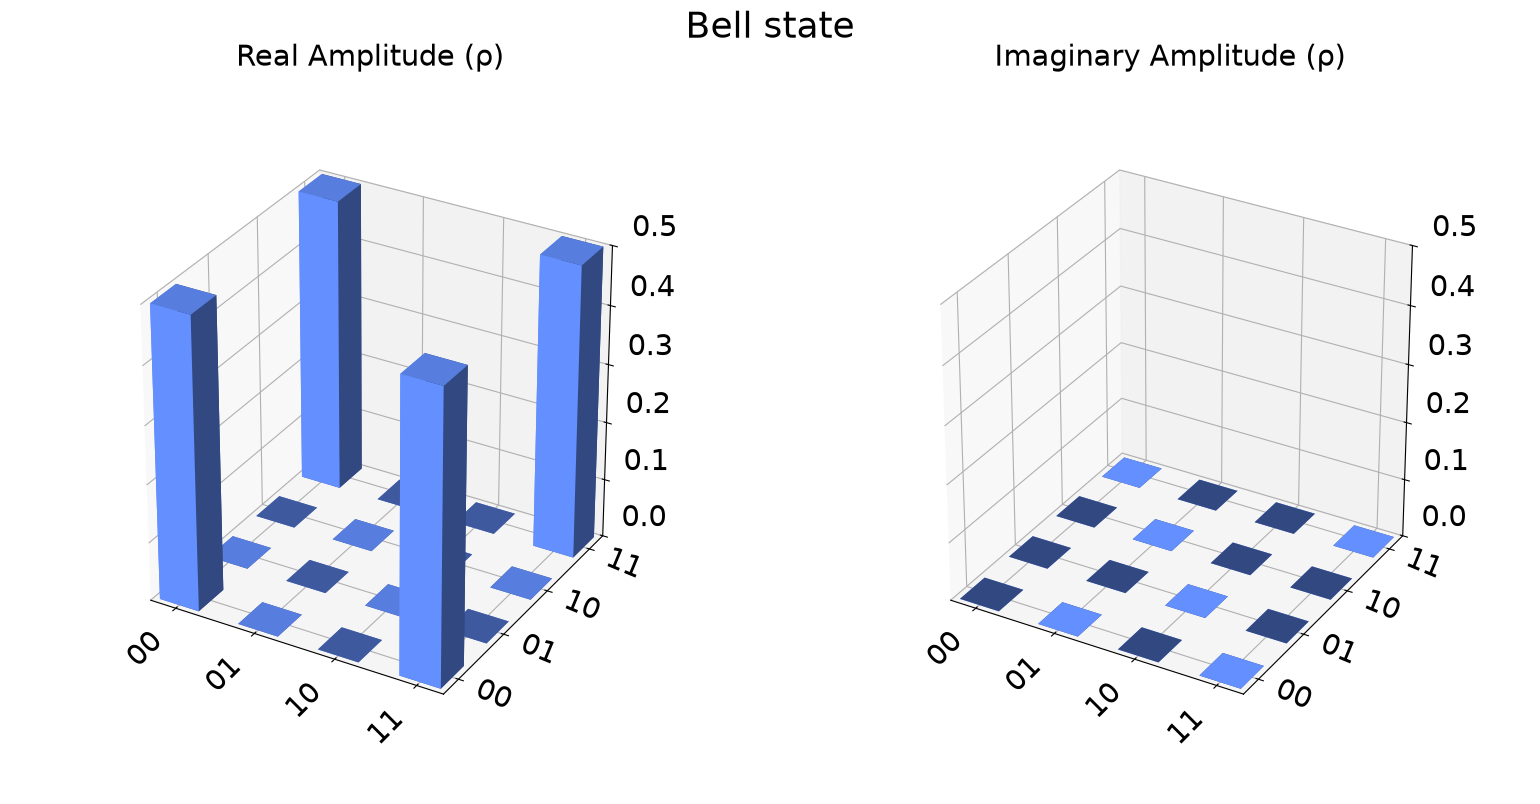

In [1]:
%matplotlib inline

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

circ_bell = QuantumCircuit(2)

circ_bell.h(0) # H gate on the first qubit
circ_bell.cx(0,1) # CNOT gate with control on the first qubit and target on the second

# Copy for hardware
circ_meas = circ_bell.copy()
circ_meas.measure_all()

circ_bell.save_density_matrix()

# Transpile for simulator
simulator = AerSimulator(method='density_matrix')
circ_bell = transpile(circ_bell, simulator)

# Run and get density matrix
result = simulator.run(circ_bell).result()
density_matrix = result.data(0)["density_matrix"]

print(density_matrix)
plot_state_city(density_matrix, title='Bell state');

In [2]:
result = simulator.run(circ_meas, shots=1000).result()
counts = result.get_counts()

print(counts)

{'11': 507, '00': 493}


Now, we are going to directly access the amplitudes and probabilities of the states. For that, we need to remove the measurement and use the statevector simulator

In [3]:
import qiskit.quantum_info as qi

circ_bell = QuantumCircuit(2)

circ_bell.h(0)
circ_bell.cx(0, 1)

# Get statevector directly
state = qi.Statevector.from_instruction(circ_bell)

# Access amplitudes
print("Amplitudes:")
for i in range(4):

    s = format(i, "02b") # b → Convert index to binary, 2 → width of 2 characters, 0 → fill missing positions with zeros

    print("Amplitude of", s, "=", state[i])

print("--------")

# Access probabilities
print("Probabilities:")
probabilities = state.probabilities()

for i in range(4):

    s = format(i, "02b")

    print("Probability of", s, "=", probabilities[i])

Amplitudes:
Amplitude of 00 = (0.7071067811865475+0j)
Amplitude of 01 = 0j
Amplitude of 10 = 0j
Amplitude of 11 = (0.7071067811865475+0j)
--------
Probabilities:
Probability of 00 = 0.4999999999999999
Probability of 01 = 0.0
Probability of 10 = 0.0
Probability of 11 = 0.4999999999999999


We are going to run the circuit on an actual computer. To reduce the wait, we would like to execute on the computer with the fewest pending jobs. We can check their properties, after loading our account, with the order *backend_overview()*

In [ ]:
RUN_IBM_HARDWARE = False
# Optional IBM Quantum hardware section. Set RUN_IBM_HARDWARE to True only after configuring a local provider account.
if RUN_IBM_HARDWARE:
    from qiskit_ibm_runtime import (
        QiskitRuntimeService,
        SamplerV2 as Sampler
    )

    # Optional IBM Quantum hardware section. Configure a local IBM Quantum account before running this section.
    # No credential is stored in this notebook or repository.

else:
    print("Skipping optional IBM Quantum hardware section.")


We can also access more details of a particular computer with the following command

In [ ]:
# Optional IBM Quantum hardware section. Run only after setting RUN_IBM_HARDWARE = True in the setup cell.
if RUN_IBM_HARDWARE:
    service = QiskitRuntimeService()
    backend = service.least_busy(
        operational=True,
        simulator=False
    )
else:
    print("Skipping optional IBM Quantum hardware section.")


In [ ]:
# Optional IBM Quantum hardware section. Run only after setting RUN_IBM_HARDWARE = True in the setup cell.
if RUN_IBM_HARDWARE:
    ### Find least-busy real backend with >1 qubit
    backends = [backend for backend in service.backends(simulator=False,operational=True)if backend.num_qubits > 1]

    ### Choose the backend with the smallest number of pending jobs.
    backend = min(backends, key=lambda backend: backend.status().pending_jobs)

    print("Executing on:", backend)
    print("Pending jobs:", backend.status().pending_jobs)
else:
    print("Skipping optional IBM Quantum hardware section.")


In [ ]:
# Optional IBM Quantum hardware section. Run only after setting RUN_IBM_HARDWARE = True in the setup cell.
if RUN_IBM_HARDWARE:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )

    isa_circ = pm.run(circ_meas)

    sampler = Sampler(mode=backend)

    job_exp = sampler.run(
        [isa_circ],
        shots=1000
    )

    result_exp = job_exp.result()

    counts_exp = result_exp[0].data.meas.get_counts()

    print("Backend:", sampler.backend().name)
    print("Counts:", counts_exp)
    print("Total shots:", sum(counts_exp.values()))

    plot_histogram([counts_exp,counts], legend=['Device', 'Simulator']);
else:
    print("Skipping optional IBM Quantum hardware section.")


We are going to select the least busy device and run our circuit on it

Once that we have run the job, we draw the results and compare them to the one obtained by the simulator

global phase: 3π/4
         ┌─────────┐┌────┐┌─────────┐                                ░ ┌─┐   
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────────────────░─┤M├───
         ├─────────┤├────┤├─────────┤ │ ┌─────────┐┌────┐┌─────────┐ ░ └╥┘┌─┐
q_1 -> 1 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░──╫─┤M├
         └─────────┘└────┘└─────────┘   └─────────┘└────┘└─────────┘ ░  ║ └╥┘
 meas: 2/═══════════════════════════════════════════════════════════════╩══╩═
                                                                        0  1 


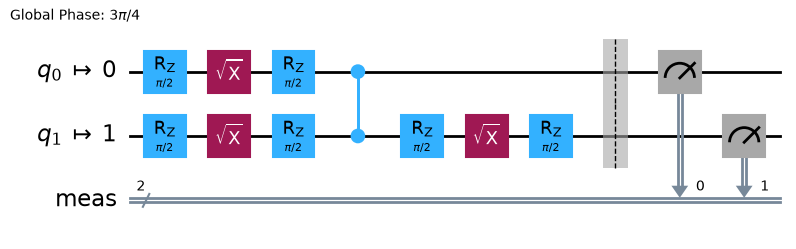

In [10]:
isa_circ.draw("mpl", idle_wires=False);
print(isa_circ);